In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [2]:
segmentations_folder_path = r"/home/chest_ct/code/data/segmentations/segmentations"

files = [
    f for f in os.listdir(segmentations_folder_path)
    if os.path.isfile(os.path.join(segmentations_folder_path, f))
]

# Exploratory Data Analysis

## CT-RATE

In [3]:
train_labels = pd.read_csv(r"/home/chest_ct/code/data/ct-rate/train_labels.csv")
valid_labels = pd.read_csv(r"/home/chest_ct/code/data/ct-rate/valid_labels.csv")
print("No of train labels:", train_labels["VolumeName"].nunique())
print("No of valid labels:", valid_labels["VolumeName"].nunique())
print("Total labels:", train_labels["VolumeName"].nunique() + valid_labels["VolumeName"].nunique())

No of train labels: 47149
No of valid labels: 3039
Total labels: 50188


In [4]:
train_labels.head()

,VolumeName,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
0,train_1_a_1.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
1,train_1_a_2.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
2,train_2_a_1.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
3,train_2_a_2.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
4,train_3_a_1.nii.gz,0,1,1,0,1,0,1,0,0,1,1,1,0,0,1,0,1,0


In [5]:
# Count of positive cases per label
label_counts = train_labels.drop("VolumeName", axis=1).sum().sort_values(ascending=False)
print(label_counts)

Lung nodule                           21382
Lung opacity                          17420
Arterial wall calcification           13377
Pulmonary fibrotic sequela            12589
Atelectasis                           12263
Lymphadenopathy                       12221
Coronary artery wall calcification    12025
Emphysema                              9122
Consolidation                          8319
Hiatal hernia                          6751
Medical material                       5818
Pleural effusion                       5705
Cardiomegaly                           5308
Peribronchial thickening               4973
Bronchiectasis                         4732
Interlobular septal thickening         3745
Mosaic attenuation pattern             3638
Pericardial effusion                   3412
dtype: int64


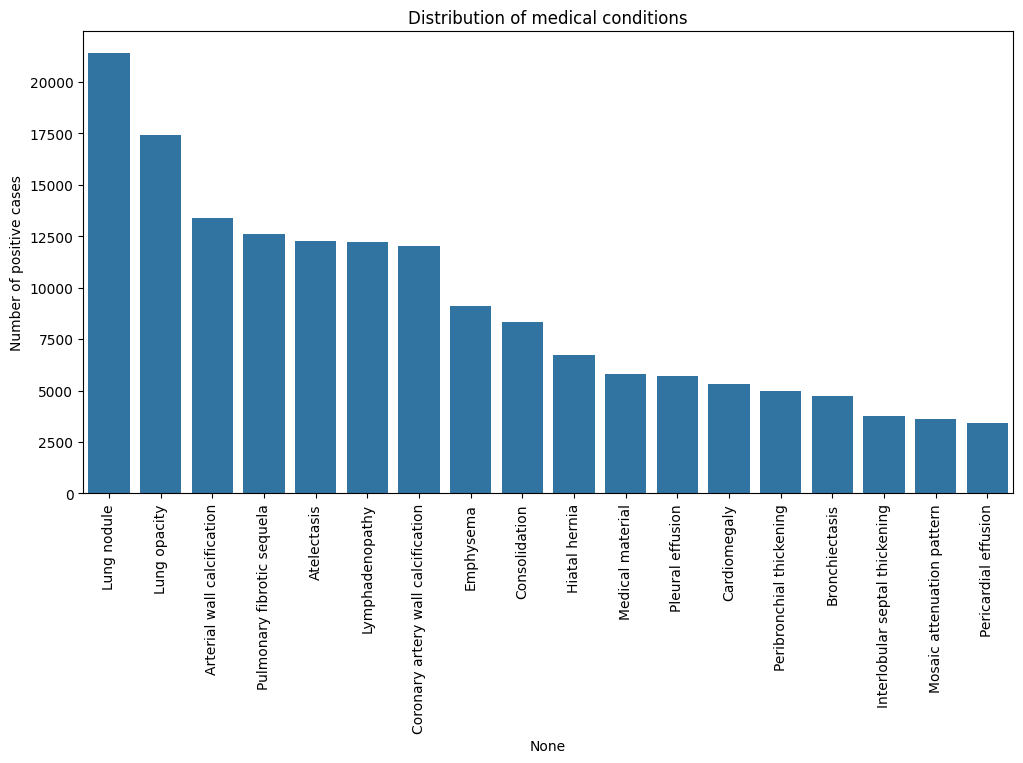

In [6]:
plt.figure(figsize=(12,6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Number of positive cases")
plt.title("Distribution of medical conditions")
plt.show()

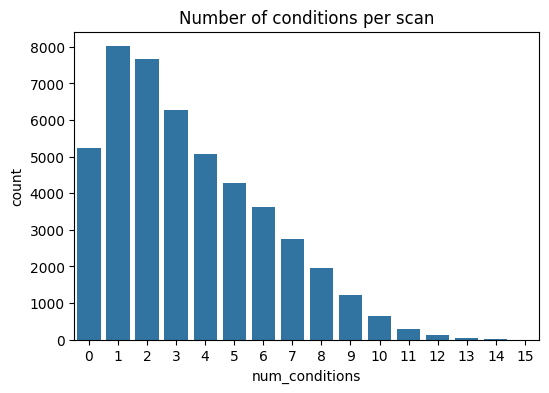

In [7]:
# Count of positive labels per scan
train_labels['num_conditions'] = train_labels.drop("VolumeName", axis=1).sum(axis=1)

plt.figure(figsize=(6,4))
sns.countplot(x='num_conditions', data=train_labels)
plt.title("Number of conditions per scan")
plt.show()

train_labels = train_labels.drop("num_conditions", axis=1)

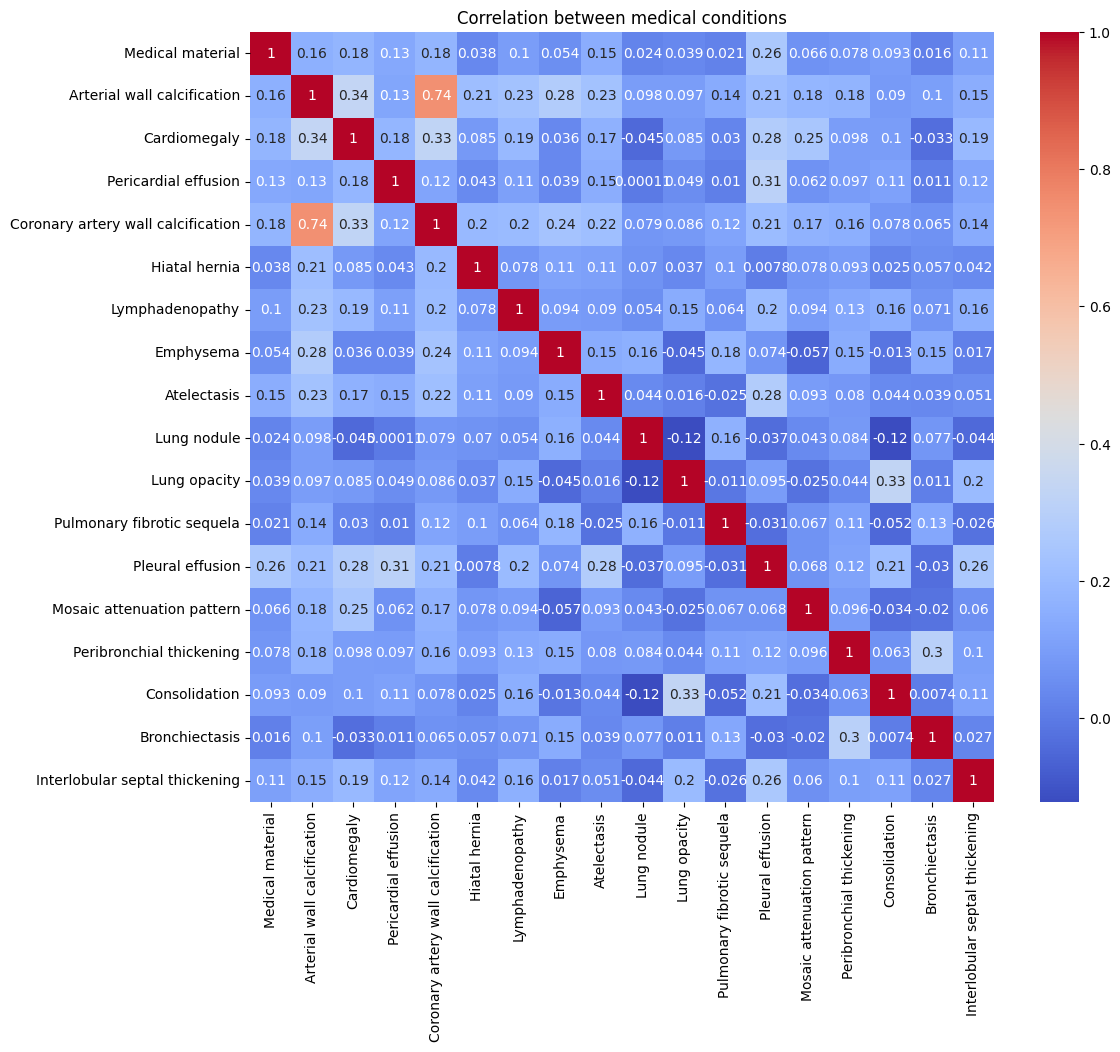

In [8]:
corr_matrix = train_labels.drop("VolumeName", axis=1).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation between medical conditions")
plt.show()

In [9]:
# Unstack into pairs
corr_pairs = corr_matrix.unstack()

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Remove duplicate pairs
corr_pairs = corr_pairs.to_frame('correlation')
corr_pairs['sorted_index'] = corr_pairs.index.map(lambda x: tuple(sorted(x)))
corr_pairs = corr_pairs.groupby('sorted_index')['correlation'].first()

# Sort by absolute correlation
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Display top correlations
print(corr_pairs.head(10))

sorted_index
(Arterial wall calcification, Coronary artery wall calcification)    0.744473
(Arterial wall calcification, Cardiomegaly)                          0.338042
(Consolidation, Lung opacity)                                        0.329736
(Cardiomegaly, Coronary artery wall calcification)                   0.327012
(Pericardial effusion, Pleural effusion)                             0.311286
(Bronchiectasis, Peribronchial thickening)                           0.301695
(Atelectasis, Pleural effusion)                                      0.280365
(Cardiomegaly, Pleural effusion)                                     0.278330
(Arterial wall calcification, Emphysema)                             0.277502
(Medical material, Pleural effusion)                                 0.259041
Name: correlation, dtype: float64


In [10]:
# check how many scans have Arterial wall calcification but not Coronary artery wall calcification
arterial_only = train_labels[
    (train_labels["Arterial wall calcification"] == 1) &
    (train_labels["Coronary artery wall calcification"] == 0)
]
print(f"Scans with Arterial wall calcification only: {len(arterial_only)}")

# check how many scans have Coronary artery wall calcification but not Arterial wall calcification
coronary_only = train_labels[
    (train_labels["Arterial wall calcification"] == 0) &
    (train_labels["Coronary artery wall calcification"] == 1)
]
print(f"Scans with Coronary artery wall calcification only: {len(coronary_only)}")

# check how many scans have both Arterial and Coronary artery wall calcifications
both = train_labels[
    (train_labels["Arterial wall calcification"] == 1) &
    (train_labels["Coronary artery wall calcification"] == 1)
]
print(f"Scans with both Arterial and Coronary artery wall calcifications: {len(both)}")

Scans with Arterial wall calcification only: 3068
Scans with Coronary artery wall calcification only: 1716
Scans with both Arterial and Coronary artery wall calcifications: 10309


## RexGroundingCT

In [11]:
filtered_train_labels = train_labels[train_labels["VolumeName"].isin(files)]
filtered_valid_labels = valid_labels[valid_labels["VolumeName"].isin(files)]
print("Number of filtered train labels:", filtered_train_labels["VolumeName"].nunique())
print("Number of filtered validation labels:", filtered_valid_labels["VolumeName"].nunique())
print("Total number of filtered files:", len(files))

Number of filtered train labels: 2628
Number of filtered validation labels: 414
Total number of filtered files: 3042


In [12]:
# Count of positive cases per label
filtered_label_counts = filtered_train_labels.drop("VolumeName", axis=1).sum().sort_values(ascending=False)
print(filtered_label_counts)

Lung nodule                           1333
Lung opacity                          1115
Pulmonary fibrotic sequela             584
Atelectasis                            583
Consolidation                          499
Lymphadenopathy                        485
Emphysema                              416
Arterial wall calcification            313
Coronary artery wall calcification     299
Bronchiectasis                         237
Pleural effusion                       204
Medical material                       197
Peribronchial thickening               185
Interlobular septal thickening         157
Pericardial effusion                   119
Cardiomegaly                           115
Mosaic attenuation pattern             109
Hiatal hernia                            9
dtype: int64


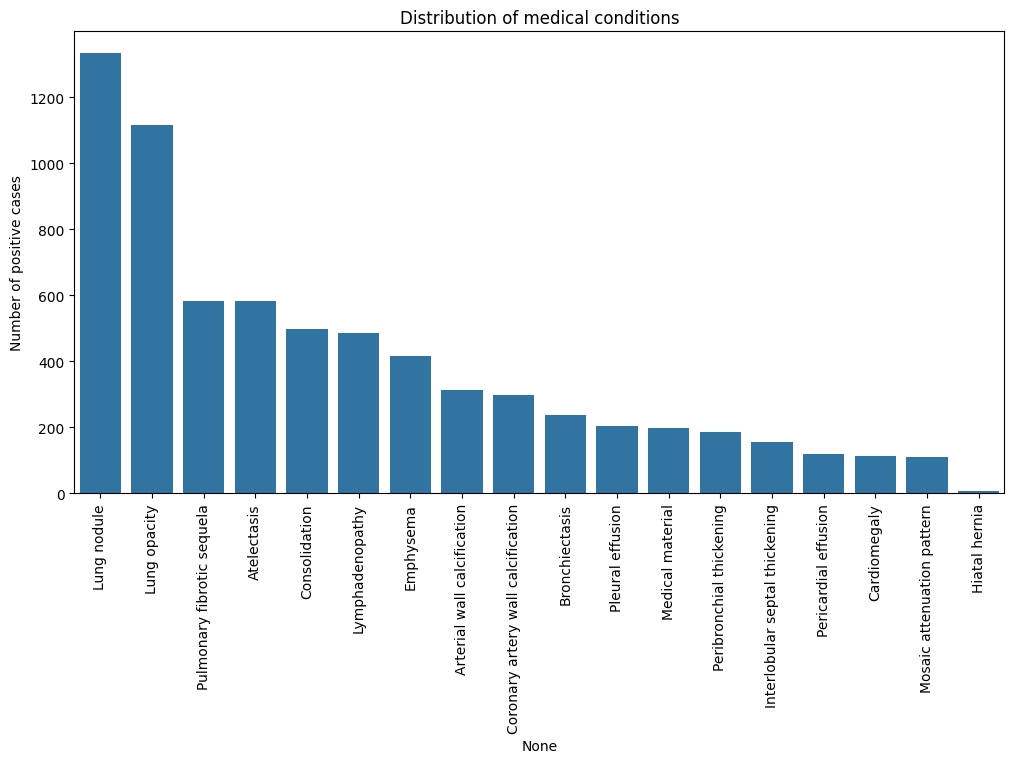

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(x=filtered_label_counts.index, y=filtered_label_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Number of positive cases")
plt.title("Distribution of medical conditions")
plt.show()

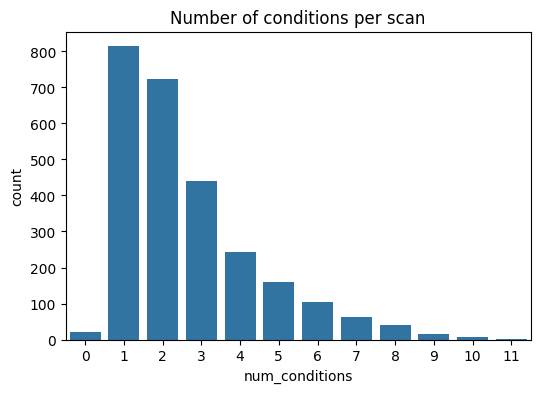

In [14]:
# Count of positive labels per scan
filtered_train_labels['num_conditions'] = filtered_train_labels.drop("VolumeName", axis=1).sum(axis=1)

plt.figure(figsize=(6,4))
sns.countplot(x='num_conditions', data=filtered_train_labels)
plt.title("Number of conditions per scan")
plt.show()

filtered_train_labels = filtered_train_labels.drop("num_conditions", axis=1)

In [15]:
print(label_counts)

Lung nodule                           21382
Lung opacity                          17420
Arterial wall calcification           13377
Pulmonary fibrotic sequela            12589
Atelectasis                           12263
Lymphadenopathy                       12221
Coronary artery wall calcification    12025
Emphysema                              9122
Consolidation                          8319
Hiatal hernia                          6751
Medical material                       5818
Pleural effusion                       5705
Cardiomegaly                           5308
Peribronchial thickening               4973
Bronchiectasis                         4732
Interlobular septal thickening         3745
Mosaic attenuation pattern             3638
Pericardial effusion                   3412
dtype: int64


In [16]:
print(filtered_label_counts)

Lung nodule                           1333
Lung opacity                          1115
Pulmonary fibrotic sequela             584
Atelectasis                            583
Consolidation                          499
Lymphadenopathy                        485
Emphysema                              416
Arterial wall calcification            313
Coronary artery wall calcification     299
Bronchiectasis                         237
Pleural effusion                       204
Medical material                       197
Peribronchial thickening               185
Interlobular septal thickening         157
Pericardial effusion                   119
Cardiomegaly                           115
Mosaic attenuation pattern             109
Hiatal hernia                            9
dtype: int64


In [17]:
# Check if any files names in train_not_chest.txt are present in the filtered dataset
with open("/home/chest_ct/code/data/ct-rate/train_not_chest.txt", "r") as f:
    train_filenames = [os.path.basename(line.strip()) for line in f]

present_files = train_labels[train_labels["VolumeName"].isin(train_filenames)]
print("Files in train_not_chest.txt that are present in ct-rate:", present_files["VolumeName"].count())

with open("/home/chest_ct/code/data/ct-rate/valid_not_chest.txt", "r") as f:
    valid_filenames = [os.path.basename(line.strip()) for line in f]

present_files = valid_labels[valid_labels["VolumeName"].isin(valid_filenames)]
print("Files in valid_not_chest.txt that are present in ct-rate:", present_files["VolumeName"].count())

Files in train_not_chest.txt that are present in ct-rate: 752
Files in valid_not_chest.txt that are present in ct-rate: 37


In [18]:
train_no_condition = train_labels.drop("VolumeName", axis=1).sum(axis=1) == 0
train_no_condition_volumes = set(train_labels[train_no_condition]["VolumeName"])
valid_no_condition = valid_labels.drop("VolumeName", axis=1).sum(axis=1) == 0
valid_no_condition_volumes = set(valid_labels[valid_no_condition]["VolumeName"])

train_overlap = train_no_condition_volumes.intersection(train_filenames)
valid_overlap = valid_no_condition_volumes.intersection(valid_filenames)

print("Train overlap count:", len(train_overlap))
print("Valid overlap count:", len(valid_overlap))

Train overlap count: 61
Valid overlap count: 6


In [19]:
valid_overlap

{'valid_208_a_1.nii.gz',
 'valid_208_a_2.nii.gz',
 'valid_208_a_4.nii.gz',
 'valid_340_a_1.nii.gz',
 'valid_340_a_2.nii.gz',
 'valid_340_a_4.nii.gz'}

In [20]:

with open('/home/chest_ct/code/data/rexgrounding-ct/dataset.json', 'r', encoding='utf-8') as file:
    rex_data = json.load(file)

In [21]:
rex_df = pd.DataFrame(rex_data["train"])
rex_df

,name,findings,entity_counts,shape,pixels,categories,protocol
0,train_1741_b_2.nii.gz,{'0': 'Irregularly circumscribed nodular conso...,{'0': 1},"[512, 512, 238]",{'0': 15571},{'0': '2b'},protocol1
1,train_1935_a_1.nii.gz,{'0': 'Segmental and subsegmental peribronchia...,"{'0': 2, '1': 3, '2': 2, '3': 3, '4': 3}","[512, 512, 264]","{'0': 101934, '1': 315619, '2': 10405, '3': 70...","{'0': '1a', '1': '2c', '2': '1d', '3': '1c', '...",protocol1
2,train_1591_f_2.nii.gz,{'0': 'Regression of consolidation areas in th...,"{'0': 2, '1': 1, '2': 1, '3': 1, '4': 2}","[512, 512, 466]","{'0': 43449, '1': 79203, '2': 2894, '3': 30384...","{'0': '2b', '1': '2b', '2': '2b', '3': '2b', '...",protocol1
3,train_1742_c_2.nii.gz,{'0': 'Nodular lesions with ground glass opaci...,"{'0': 2, '1': 3, '2': 3}","[512, 512, 448]","{'0': 10915, '1': 1449, '2': 1399913}","{'0': '2c', '1': '2d', '2': '1c'}",protocol1
4,train_1968_b_1.nii.gz,{'0': 'Significant progression of parenchymal ...,"{'0': 2, '1': 3}","[512, 512, 252]","{'0': 1051286, '1': 36068}","{'0': '2b', '1': '2a'}",protocol1
...,...,...,...,...,...,...,...
2987,valid_1249_a_1.nii.gz,{'0': 'Centrilobular nodular consolidation are...,"{'0': 1, '1': 1}","[512, 512, 220]","{'0': 46541, '1': 57879}","{'0': '2b', '1': '1a'}",protocol1
2988,train_860_a_1.nii.gz,{'0': 'Minimal peribronchial thickening in the...,"{'0': 2, '1': 3, '2': 1}","[512, 512, 269]","{'0': 103724, '1': 1998, '2': 925}","{'0': '1a', '1': '2d', '2': '2d'}",protocol1
2989,train_914_a_2.nii.gz,{'0': 'A few subcentimeter nonspecific nodules...,{'0': 2},"[512, 512, 493]",{'0': 3258},{'0': '2d'},protocol1
2990,valid_939_a_2.nii.gz,{'0': 'Extensive area of consolidation in the ...,"{'0': 1, '1': 1, '2': 1, '3': 1}","[512, 512, 461]","{'0': 383935, '1': 383935, '2': 383935, '3': 3...","{'0': '2b', '1': '2h', '2': '2b', '3': '2c'}",protocol1


In [22]:
segmentations_folder_path = r"/home/chest_ct/code/data/segmentations/segmentations"

segmentations = [
    f for f in os.listdir(segmentations_folder_path)
    if os.path.isfile(os.path.join(segmentations_folder_path, f))
]

train_labels = pd.read_csv("/home/chest_ct/code/data/ct-rate/train_labels.csv")

files = []
# Iterate over the rows of the dataframe
for index, row in train_labels.iterrows():
    if row["Consolidation"] == 1 or row["Atelectasis"] == 1 or row["Bronchiectasis"] == 1 or row["Arterial wall calcification"] == 1 or row["Coronary artery wall calcification"] == 1 or row["Lung nodule"] == 1 or row["Lung opacity"] == 1:
        if row["VolumeName"] in segmentations:
            files.append(row["VolumeName"])

In [23]:
print(len(files))

2416


In [24]:
shortlisted_train_labels = pd.DataFrame(train_labels[train_labels["VolumeName"].isin(files)])
shortlisted_train_labels

,VolumeName,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
12,train_6_a_2.nii.gz,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
21,train_9_a_1.nii.gz,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
26,train_11_a_2.nii.gz,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
28,train_12_a_2.nii.gz,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
46,train_20_a_2.nii.gz,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32854,train_13889_a_2.nii.gz,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
32856,train_13890_a_2.nii.gz,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
32868,train_13896_b_1.nii.gz,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
32905,train_13911_a_1.nii.gz,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [25]:
shortlisted_abnormalities = [
    "Atelectasis",
    "Lung nodule",
    "Lung opacity",
    "Consolidation",
    "Arterial wall calcification",
    "Coronary artery wall calcification",
    "Bronchiectasis",
]

In [26]:
# Columns that should NOT have any 1s
non_shortlisted_columns = [
    col for col in shortlisted_train_labels.columns
    if col not in shortlisted_abnormalities and col != "VolumeName"
]

# Step 1: filter rows
filtered_df = shortlisted_train_labels[
    ~shortlisted_train_labels[non_shortlisted_columns].eq(1).any(axis=1)
]

# Step 2: keep only desired columns
shortlisted_abnormalities_df = filtered_df[["VolumeName"] + shortlisted_abnormalities]
shortlisted_abnormalities_df

,VolumeName,Atelectasis,Lung nodule,Lung opacity,Consolidation,Arterial wall calcification,Coronary artery wall calcification,Bronchiectasis
21,train_9_a_1.nii.gz,0,1,0,0,0,0,0
26,train_11_a_2.nii.gz,0,0,1,1,0,0,0
83,train_37_a_2.nii.gz,1,1,0,1,0,1,0
155,train_56_a_1.nii.gz,0,0,1,1,0,0,0
162,train_59_a_2.nii.gz,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
32854,train_13889_a_2.nii.gz,0,1,0,0,0,0,0
32856,train_13890_a_2.nii.gz,0,0,1,1,0,0,0
32868,train_13896_b_1.nii.gz,1,0,0,0,0,0,0
32905,train_13911_a_1.nii.gz,0,1,0,0,0,0,0


In [27]:
shortlisted_label_counts = shortlisted_train_labels.drop("VolumeName", axis=1).sum().sort_values(ascending=False)
print(shortlisted_label_counts)

Lung nodule                           1333
Lung opacity                          1115
Atelectasis                            583
Consolidation                          499
Pulmonary fibrotic sequela             479
Lymphadenopathy                        468
Emphysema                              356
Arterial wall calcification            313
Coronary artery wall calcification     299
Bronchiectasis                         237
Pleural effusion                       193
Medical material                       187
Peribronchial thickening               168
Interlobular septal thickening         153
Cardiomegaly                           113
Pericardial effusion                   110
Mosaic attenuation pattern              95
Hiatal hernia                            9
dtype: int64


In [28]:
final_abnormalities = [
    "Atelectasis",
    "Lung nodule",
    "Lung opacity",
    "Consolidation",
]

In [29]:
# Columns that should NOT have any 1s
non_final_columns = [
    col for col in shortlisted_train_labels.columns
    if col not in final_abnormalities and col != "VolumeName"
]

# Step 1: filter rows
filtered_df = shortlisted_train_labels[
    ~shortlisted_train_labels[non_final_columns].eq(1).any(axis=1)
]

# Step 2: keep only desired columns
final_abnormalities_df = filtered_df[["VolumeName"] + final_abnormalities]
final_abnormalities_df

,VolumeName,Atelectasis,Lung nodule,Lung opacity,Consolidation
21,train_9_a_1.nii.gz,0,1,0,0
26,train_11_a_2.nii.gz,0,0,1,1
155,train_56_a_1.nii.gz,0,0,1,1
162,train_59_a_2.nii.gz,0,1,0,0
190,train_67_a_2.nii.gz,0,0,1,0
...,...,...,...,...,...
32854,train_13889_a_2.nii.gz,0,1,0,0
32856,train_13890_a_2.nii.gz,0,0,1,1
32868,train_13896_b_1.nii.gz,1,0,0,0
32905,train_13911_a_1.nii.gz,0,1,0,0


In [30]:
# find volumes that have ateletasis
atelectasis_volumes = final_abnormalities_df[final_abnormalities_df["Lung nodule"] == 1]
print(f"Number of volumes with Atelectasis: {len(atelectasis_volumes)}")

Number of volumes with Atelectasis: 546


Lung nodule      546
Lung opacity     463
Consolidation    177
Atelectasis      156
dtype: int64


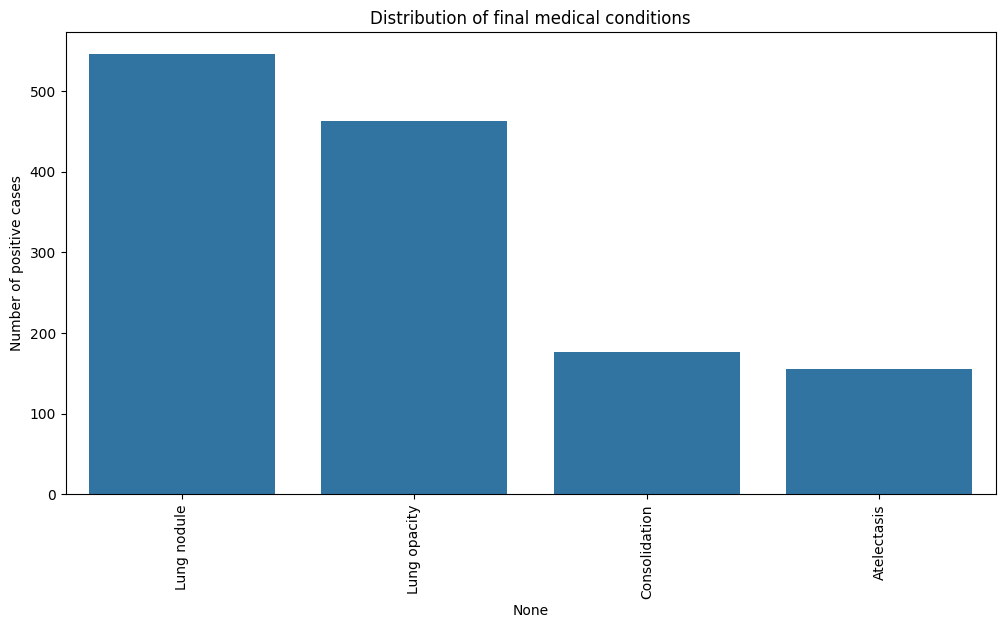

In [31]:
# find colummns where all columns except VolumeName are 0
normal_ct_count = final_abnormalities_df.drop("VolumeName", axis=1).sum(axis=1) == 4
normal_ct_count.sum()

# create bar chart of the distribution of the final abnormalities
final_label_counts = final_abnormalities_df.drop("VolumeName", axis=1).sum().sort_values(ascending=False)
print(final_label_counts)

plt.figure(figsize=(12,6))
sns.barplot(x=final_label_counts.index, y=final_label_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Number of positive cases")
plt.title("Distribution of final medical conditions")
plt.show()

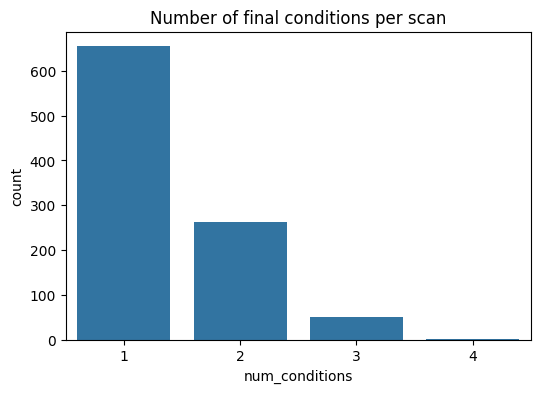

In [32]:
# create bar chart of the number of final abnormalities per ct
final_abnormalities_df['num_conditions'] = final_abnormalities_df.drop("VolumeName", axis=1).sum(axis=1)
plt.figure(figsize=(6,4))
sns.countplot(x='num_conditions', data=final_abnormalities_df)
plt.title("Number of final conditions per scan")
plt.show()

In [33]:
# find how many of the VolumeNames in final_abnormalities_df are present in the dataset_transformed.json (json structure" training -> image
with open("/home/chest_ct/code/data/rexgrounding-ct/dataset_transformed_filtered.json", "r") as f:
    dataset_json = json.load(f)

training_list = dataset_json.get("training") or dataset_json.get("train") or []
dataset_volume_names = set(os.path.basename(item.get("image", "")) for item in training_list if item.get("image"))
final_abnormalities_volume_names = set(final_abnormalities_df["VolumeName"])
overlap_volume_names = dataset_volume_names.intersection(final_abnormalities_volume_names)
print(f"Number of overlapping VolumeNames: {len(overlap_volume_names)}")

Number of overlapping VolumeNames: 165


In [34]:
# find how many atelectasis_volumes are in the overlapping_Volume_Names when atelectasis_volumes = final_abnormalities_df[final_abnormalities_df["Atelectasis"] == 1]
atelectasis_overlap = final_abnormalities_df[
    (final_abnormalities_df["VolumeName"].isin(atelectasis_volumes["VolumeName"])) &
    (final_abnormalities_df["VolumeName"].isin(overlap_volume_names))
]
print(f"Number of Atelectasis volumes in overlap: {len(atelectasis_overlap)}")

Number of Atelectasis volumes in overlap: 162


In [35]:
atelectasis_overlap

,VolumeName,Atelectasis,Lung nodule,Lung opacity,Consolidation,num_conditions
162,train_59_a_2.nii.gz,0,1,0,0,1
260,train_93_c_2.nii.gz,0,1,1,1,3
452,train_176_a_2.nii.gz,0,1,0,0,1
559,train_225_a_1.nii.gz,0,1,0,0,1
567,train_229_a_1.nii.gz,0,1,0,0,1
...,...,...,...,...,...,...
32573,train_13757_a_2.nii.gz,0,1,0,0,1
32665,train_13804_a_2.nii.gz,0,1,1,0,2
32727,train_13832_a_2.nii.gz,0,1,0,0,1
32823,train_13875_b_1.nii.gz,0,1,0,0,1


## LC-KSVD post-training export

The next cells load the saved model pickles, export metrics, and generate localization outputs.
Set the paths before running.

In [40]:
from pathlib import Path
import json
import pickle
import sys

import numpy as np

# Update these paths as needed
SRC_DIR = Path("/home/chest_ct/code/models/lc-ksvd/src")
MODELS_DIR = Path("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models")
RESULTS_DIR = Path("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results")
DATASET_ROOT = Path("/home/chest_ct/code/data")

# Add lc-ksvd src to import path
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from lc_ksvd.data_loader import load_volume, load_mask, MetadataRegistry, ScanLoader
from lc_ksvd.localize import LocalizationEngine

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "Lung nodule": MODELS_DIR / "Lung nodule_lcksvd2.pkl",
    "Lung opacity": MODELS_DIR / "Lung opacity_lcksvd2.pkl",
    "Consolidation": MODELS_DIR / "Consolidation_lcksvd2.pkl",
}

# Configure which scans to localize for each abnormality
SCAN_IDS_TO_LOCALIZE = {
    "Lung nodule": ["train_37_a_2"],
    "Lung opacity": ["train_37_a_2"],
    "Consolidation": ["train_37_a_2"],
}


In [41]:
# Export train/val metrics from the saved model pickles
metrics = {}

for ab, model_path in MODEL_PATHS.items():
    if not model_path.exists():
        print(f"Skipping {ab}: missing model file {model_path}")
        continue

    with open(model_path, "rb") as f:
        payload = pickle.load(f)

    metrics[ab] = {
        "abnormality": ab,
        "model_path": str(model_path),
        "train_metrics": payload.get("train_metrics", {}),
        "val_metrics": payload.get("val_metrics", {}),
        "lcksvd_config": payload.get("lcksvd_config", {}),
    }

metrics_path = RESULTS_DIR / "lcksvd_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics summary to {metrics_path}")
print(json.dumps(metrics, indent=2))

Saved metrics summary to /home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/lcksvd_metrics.json
{
  "Lung nodule": {
    "abnormality": "Lung nodule",
    "model_path": "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/Lung nodule_lcksvd2.pkl",
    "train_metrics": {
      "auroc": 0.5124409400999086,
      "f1": 0.5160900072586498,
      "ap": 0.511150122747835
    },
    "val_metrics": {
      "auroc": 0.5242782679434967,
      "f1": 0.5154755205402364,
      "ap": 0.5271105428920864
    },
    "lcksvd_config": {
      "n_components": 128,
      "n_nonzero_coefs": 10,
      "alpha": 4.0,
      "beta": 2.0,
      "variant": "lcksvd2",
      "n_iter": 50,
      "n_iter_init": 20,
      "verbose": true,
      "random_state": 42
    }
  },
  "Lung opacity": {
    "abnormality": "Lung opacity",
    "model_path": "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/Lung opacity_lcksvd2.pkl",
    "train_metrics": {
      "auroc": 0.8298611111111109,
      

In [42]:
# Generate contribution maps and binary localization masks
# Note: replace the scan IDs above with the volumes you want to inspect.
localization_outputs = {}

for ab, model_path in MODEL_PATHS.items():
    if not model_path.exists():
        print(f"Skipping {ab}: missing model file {model_path}")
        continue

    engine = LocalizationEngine.from_pickle(str(model_path))
    scan_ids = SCAN_IDS_TO_LOCALIZE.get(ab, [])

    if not scan_ids:
        print(f"Skipping {ab}: no scan IDs configured")
        continue

    localization_outputs[ab] = {}

    for scan_id in scan_ids:
        vol_hu, spacing = load_volume(scan_id)
        volume = engine.preprocess(vol_hu, spacing)

        contrib_map = engine.contribution_map(volume)
        binary_mask = engine.localize(volume)

        contrib_path = RESULTS_DIR / f"{ab}_{scan_id}_contrib.npy"
        mask_path = RESULTS_DIR / f"{ab}_{scan_id}_mask.npy"

        np.save(contrib_path, contrib_map)
        np.save(mask_path, binary_mask)

        localization_outputs[ab][scan_id] = {
            "contrib_path": str(contrib_path),
            "mask_path": str(mask_path),
            "contrib_shape": contrib_map.shape,
            "mask_shape": binary_mask.shape,
            "mask_sum": int(binary_mask.sum()),
        }

print(json.dumps(localization_outputs, indent=2))

INFO   Sliding window: 3840 patches (stride=16)
INFO   Sliding window: 3840 patches (stride=16)
INFO   Sliding window: 3840 patches (stride=16)
INFO   Sliding window: 3840 patches (stride=16)
INFO   Sliding window: 3840 patches (stride=16)
INFO   Sliding window: 3840 patches (stride=16)


{
  "Lung nodule": {
    "train_37_a_2": {
      "contrib_path": "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/Lung nodule_train_37_a_2_contrib.npy",
      "mask_path": "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/Lung nodule_train_37_a_2_mask.npy",
      "contrib_shape": [
        270,
        270,
        256
      ],
      "mask_shape": [
        270,
        270,
        256
      ],
      "mask_sum": 4730190
    }
  },
  "Lung opacity": {
    "train_37_a_2": {
      "contrib_path": "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/Lung opacity_train_37_a_2_contrib.npy",
      "mask_path": "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/Lung opacity_train_37_a_2_mask.npy",
      "contrib_shape": [
        270,
        270,
        256
      ],
      "mask_shape": [
        270,
        270,
        256
      ],
      "mask_sum": 4071552
    }
  },
  "Consolidation": {
    "train_37_a_2": {
      "contrib_path": "/ho

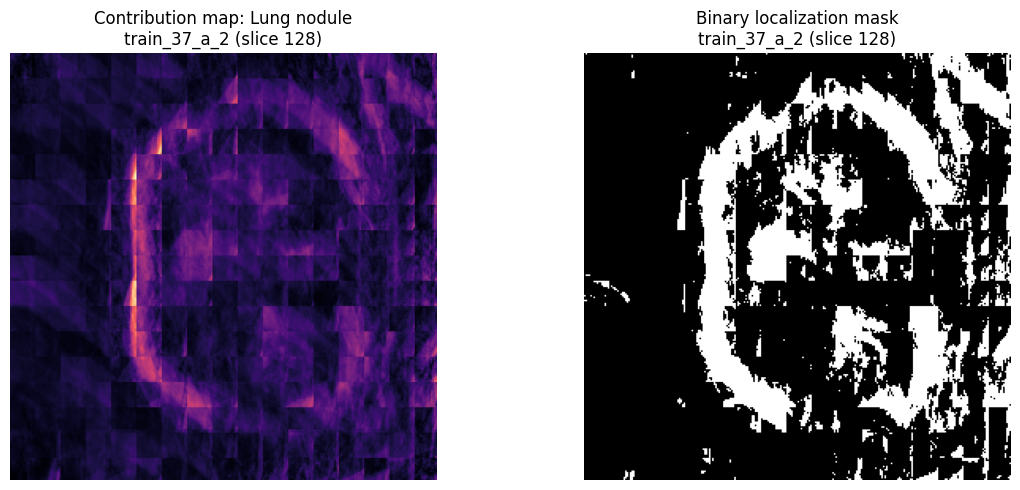

In [43]:
import matplotlib.pyplot as plt

# Quick overlay visualization for one result
# Update these two values to inspect a specific case
VIS_ABNORMALITY = "Lung nodule"
VIS_SCAN_ID = "train_37_a_2"

contrib_path = RESULTS_DIR / f"{VIS_ABNORMALITY}_{VIS_SCAN_ID}_contrib.npy"
mask_path = RESULTS_DIR / f"{VIS_ABNORMALITY}_{VIS_SCAN_ID}_mask.npy"

if contrib_path.exists() and mask_path.exists():
    contrib_map = np.load(contrib_path)
    binary_mask = np.load(mask_path)

    mid_z = contrib_map.shape[2] // 2
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(contrib_map[:, :, mid_z], cmap="magma")
    axes[0].set_title(f"Contribution map: {VIS_ABNORMALITY}\n{VIS_SCAN_ID} (slice {mid_z})")
    axes[0].axis("off")

    axes[1].imshow(binary_mask[:, :, mid_z], cmap="gray")
    axes[1].set_title(f"Binary localization mask\n{VIS_SCAN_ID} (slice {mid_z})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"Missing files for {VIS_ABNORMALITY} / {VIS_SCAN_ID}")